## Setup and Imports


In [1]:
from google.colab import drive

import os
import shutil
import zipfile
import time

import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from glob import glob
from tqdm import tqdm

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    roc_curve,
    auc,
    precision_recall_curve
)

import torch
import joblib

## Check Runtime

In [2]:
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

GPU: Tesla T4


## Loading Data to Google Colab Drive From Google Drive

In [3]:
drive.mount('/content/drive')
start_time = time.time()

BASE_PATH = "/content/cs445"

os.makedirs(BASE_PATH, exist_ok=True)

DRIVE_PATH = "/content/drive/MyDrive/CS445 Final Project/Data/Final_data"

zip_files = [
    "celebdf_final_data_processed.zip",
    "HumanvAI_processed.zip",
    "UADFV_processed.zip"
]

for z in zip_files:

    src = os.path.join(DRIVE_PATH, z)
    dst = os.path.join(BASE_PATH, z)

    print(f"Copying {z}...")

    shutil.copy(src, dst)

    print(f"Extracting {z}...")

    with zipfile.ZipFile(dst, 'r') as zip_ref:
        zip_ref.extractall(BASE_PATH)

print("Finished extraction.")

print("Runtime:",
      round((time.time() - start_time)/60, 2),
      "minutes")

Mounted at /content/drive
Copying celebdf_final_data_processed.zip...
Extracting celebdf_final_data_processed.zip...
Copying HumanvAI_processed.zip...
Extracting HumanvAI_processed.zip...
Copying UADFV_processed.zip...
Extracting UADFV_processed.zip...
Finished extraction.
Runtime: 0.56 minutes


## Verify Folder Structure

In [4]:
for root, dirs, files in os.walk(BASE_PATH):
    print(root)

/content/cs445
/content/cs445/content
/content/cs445/content/celebdf_final_data
/content/cs445/content/celebdf_final_data/Train
/content/cs445/content/celebdf_final_data/Train/Real
/content/cs445/content/celebdf_final_data/Train/Fake
/content/cs445/content/celebdf_final_data/Val
/content/cs445/content/celebdf_final_data/Val/Real
/content/cs445/content/celebdf_final_data/Val/Fake
/content/cs445/content/celebdf_final_data/Test
/content/cs445/content/celebdf_final_data/Test/Real
/content/cs445/content/celebdf_final_data/Test/Fake
/content/cs445/content/HumanvAI
/content/cs445/content/HumanvAI/train
/content/cs445/content/HumanvAI/train/Real
/content/cs445/content/HumanvAI/train/Fake
/content/cs445/content/HumanvAI/test
/content/cs445/content/HumanvAI/test/Real
/content/cs445/content/HumanvAI/test/Fake
/content/cs445/content/HumanvAI/val
/content/cs445/content/HumanvAI/val/Real
/content/cs445/content/HumanvAI/val/Fake
/content/cs445/content/UADFV_Final_data
/content/cs445/content/UADFV_Fin

## Load Dataset


In [5]:
# from google.colab import drive
# drive.mount('/content/drive')

# REAL_PATH = "/content/drive/MyDrive/Data/real"
# FAKE_PATH = "/content/drive/MyDrive/Data/fake"

TRAIN_REAL = "/content/cs445/content/celebdf_final_data/Train/Real"
TRAIN_FAKE = "/content/cs445/content/celebdf_final_data/Train/Fake"

VAL_REAL = "/content/cs445/content/celebdf_final_data/Val/Real"
VAL_FAKE = "/content/cs445/content/celebdf_final_data/Val/Fake"

TEST_REAL = "/content/cs445/content/celebdf_final_data/Test/Real"
TEST_FAKE = "/content/cs445/content/celebdf_final_data/Test/Fake"

# Preprocess Images

In [6]:
IMG_SIZE = 224
def preprocess_image(image_path):
    img = cv2.imread(image_path)

    if img is None:
        return None

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = img.astype(np.float32) / 255.0

    return img

## Image loader




In [7]:
def load_images(folder, label, max_images=2000):
    images = []
    labels = []

    files = os.listdir(folder)[:max_images]

    for file in files:
        path = os.path.join(folder, file)
        img = preprocess_image(path)

        if img is not None:
          images.append(img)
          labels.append(label)

    return images, labels

## Load Training Data

In [8]:
real_imgs, real_labels = load_images(
    TRAIN_REAL,
    label=0
)

fake_imgs, fake_labels = load_images(
    TRAIN_FAKE,
    label=1
)

X_train_images = real_imgs + fake_imgs

y_train = real_labels + fake_labels

print("Training Images:", len(X_train_images))

Training Images: 4000


##Load Validation Data

In [9]:
real_imgs, real_labels = load_images(
    VAL_REAL,
    label=0
)

fake_imgs, fake_labels = load_images(
    VAL_FAKE,
    label=1
)

X_val_images = real_imgs + fake_imgs

y_val = real_labels + fake_labels

print("Validation Images:", len(X_val_images))

Validation Images: 1500


##Load Test Data

In [10]:
real_imgs, real_labels = load_images(
    TEST_REAL,
    label=0
)

fake_imgs, fake_labels = load_images(
    TEST_FAKE,
    label=1
)

X_test_images = real_imgs + fake_imgs

y_test = real_labels + fake_labels

print("Testing Images:", len(X_test_images))

Testing Images: 1500


## FFT Transformation


In [11]:
def compute_fft(image):

    fft = np.fft.fft2(image)

    fft_shift = np.fft.fftshift(fft)

    magnitude = np.log(np.abs(fft_shift) + 1)

    return magnitude

## Visualize FFT

In [12]:
def show_fft(image):

    fft_mag = compute_fft(image)

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(image, cmap='gray')
    plt.title("Original")

    plt.subplot(1,2,2)
    plt.imshow(fft_mag, cmap='gray')
    plt.title("FFT Magnitude")

    plt.show()

## Test Visualization

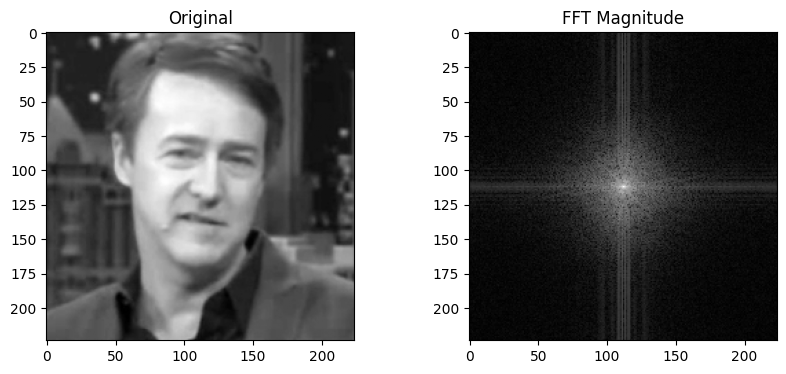

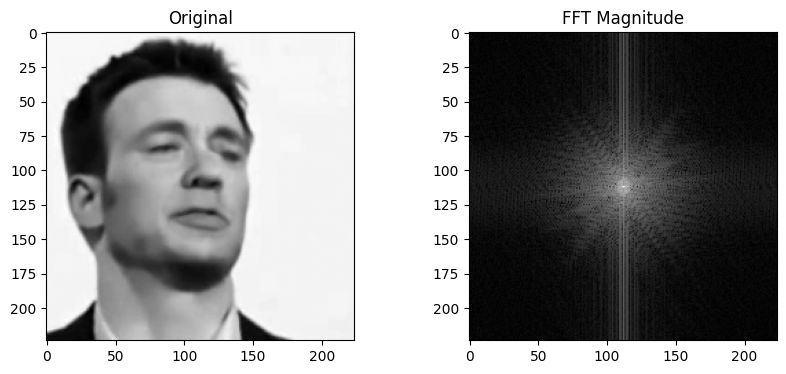

In [13]:
show_fft(X_train_images[0])

show_fft(X_train_images[-1])

## Feature Extraction

In [27]:
def extract_features(image):

    f = np.fft.fft2(image)
    fshift = np.fft.fftshift(f)

    magnitude = np.log(np.abs(fshift) + 1)

    h, w = magnitude.shape
    center_h, center_w = h // 2, w // 2

    low_freq = magnitude[
        center_h-20:center_h+20,
        center_w-20:center_w+20
    ]

    high_freq = magnitude.copy()

    high_freq[
        center_h-20:center_h+20,
        center_w-20:center_w+20
    ] = 0

    features = [

        np.mean(magnitude),
        np.std(magnitude),

        np.max(magnitude),
        np.min(magnitude),

        np.median(magnitude),

        np.mean(low_freq),
        np.std(low_freq),

        np.mean(high_freq),
        np.std(high_freq),

        np.sum(low_freq),
        np.sum(high_freq),

    ]

    return features

## Build FFT Features

In [28]:

def build_feature_matrix(images):

    feature_matrix = []

    for img in tqdm(images):

        fft_mag = compute_fft(img)

        features = extract_features(fft_mag)

        feature_matrix.append(features)

    return np.array(feature_matrix)

##Extract Train Features

In [29]:
X_train_features = build_feature_matrix(
    X_train_images
)

100%|██████████| 4000/4000 [00:17<00:00, 228.27it/s]


##Extract Validation Features

In [30]:
X_val_features = build_feature_matrix(
    X_val_images
)

100%|██████████| 1500/1500 [00:06<00:00, 246.40it/s]


##Extract Test Features

In [31]:
X_test_features = build_feature_matrix(
    X_test_images
)

100%|██████████| 1500/1500 [00:06<00:00, 234.47it/s]


##Save Features

In [32]:
np.save("X_train_features.npy", X_train_features)
np.save("X_val_features.npy", X_val_features)
np.save("X_test_features.npy", X_test_features)

np.save("y_train.npy", y_train)
np.save("y_val.npy", y_val)
np.save("y_test.npy", y_test)

##Normalize Features

In [33]:
scaler = StandardScaler()

X_train_features = scaler.fit_transform(
    X_train_features
)

X_val_features = scaler.transform(
    X_val_features
)

X_test_features = scaler.transform(
    X_test_features
)

##Train Logistic Regression

In [34]:
start_time = time.time()

model = LogisticRegression(
    max_iter=1000,
    solver='lbfgs'
)

model.fit(
    X_train_features,
    y_train
)

print("Training Runtime:",
      round((time.time() - start_time)/60, 2),
      "minutes")

Training Runtime: 0.0 minutes


##Validation Evaluation

In [35]:
y_val_pred = model.predict(
    X_val_features
)

print(classification_report(
    y_val,
    y_val_pred
))

              precision    recall  f1-score   support

           0       0.54      0.50      0.52       750
           1       0.53      0.57      0.55       750

    accuracy                           0.54      1500
   macro avg       0.54      0.54      0.54      1500
weighted avg       0.54      0.54      0.54      1500



##Final Test Evaluation

In [36]:
y_test_pred = model.predict(
    X_test_features
)

print("Accuracy:",
      accuracy_score(
          y_test,
          y_test_pred
      ))

print(classification_report(
    y_test,
    y_test_pred
))

Accuracy: 0.546
              precision    recall  f1-score   support

           0       0.55      0.52      0.54       750
           1       0.54      0.57      0.56       750

    accuracy                           0.55      1500
   macro avg       0.55      0.55      0.55      1500
weighted avg       0.55      0.55      0.55      1500



##Confusion Matrix

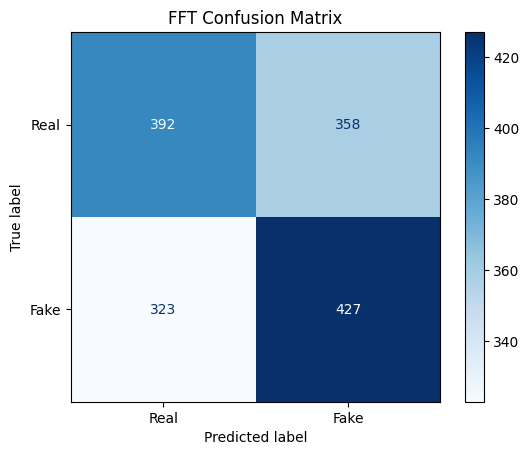

In [37]:
cm = confusion_matrix(
    y_test,
    y_test_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Real", "Fake"]
)

disp.plot(cmap="Blues")

plt.title("FFT Confusion Matrix")

plt.show()

##ROC Curve

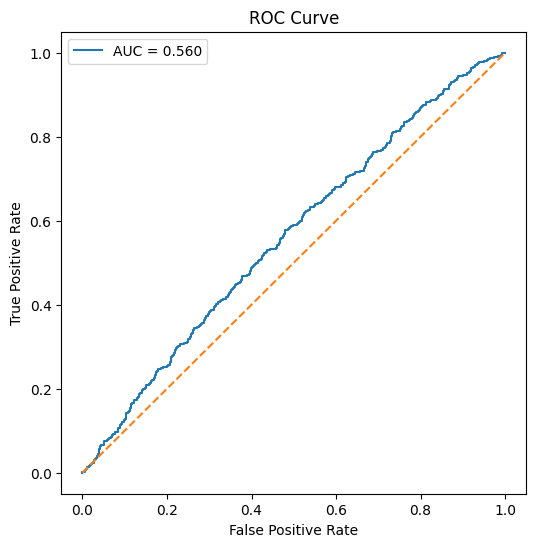

In [38]:
y_probs = model.predict_proba(
    X_test_features
)[:,1]

fpr, tpr, _ = roc_curve(
    y_test,
    y_probs
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

##Precision Recall Curve

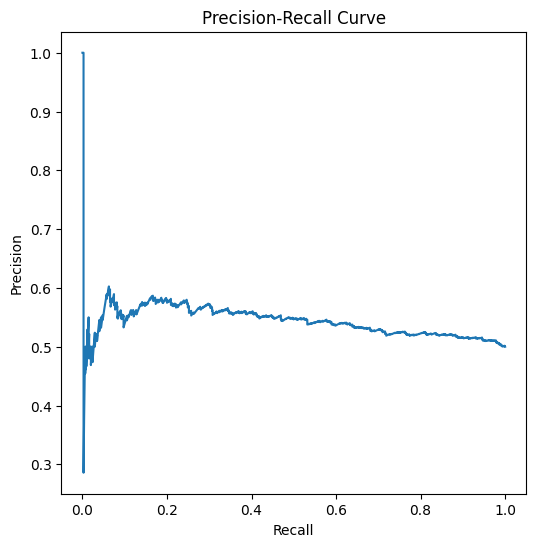

In [39]:
precision, recall, _ = precision_recall_curve(
    y_test,
    y_probs
)

plt.figure(figsize=(6,6))

plt.plot(recall, precision)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.show()

##Frequency Distribution Visualization

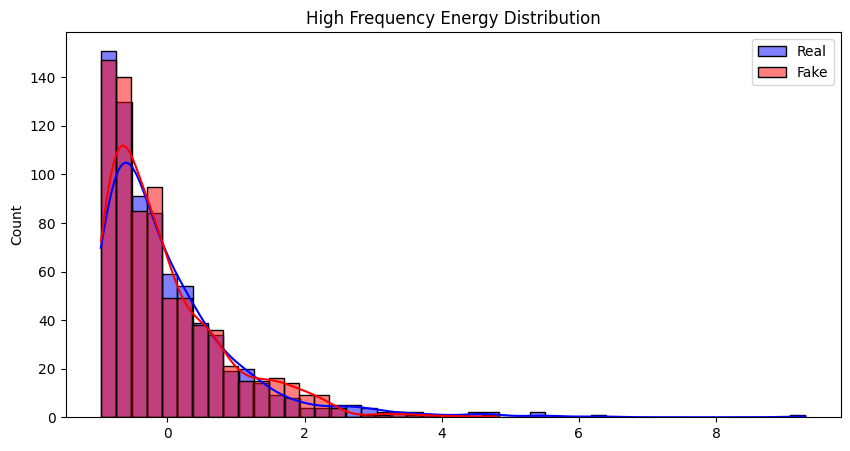

In [40]:
real_feats = X_test_features[
    np.array(y_test) == 0
]

fake_feats = X_test_features[
    np.array(y_test) == 1
]

plt.figure(figsize=(10,5))

sns.histplot(
    real_feats[:,3],
    color='blue',
    label='Real',
    kde=True
)

sns.histplot(
    fake_feats[:,3],
    color='red',
    label='Fake',
    kde=True
)

plt.legend()

plt.title(
    "High Frequency Energy Distribution"
)

plt.show()

##Classification Report Figure

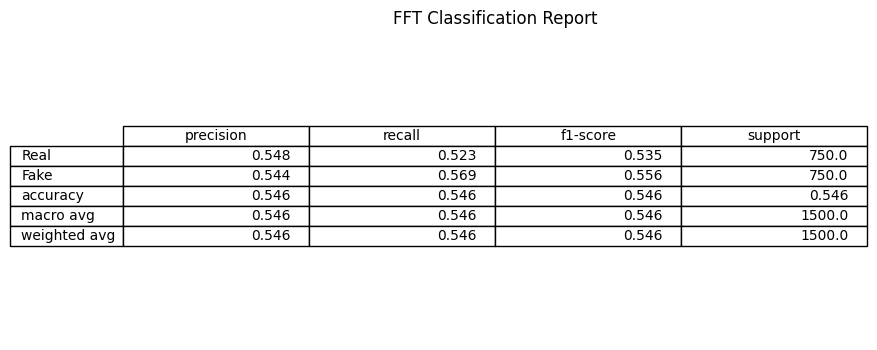

In [41]:
import matplotlib.pyplot as plt
import pandas as pd

report = classification_report(
    y_test,
    y_test_pred,
    target_names=["Real", "Fake"],
    output_dict=True
)

df = pd.DataFrame(report).transpose()

fig, ax = plt.subplots(figsize=(8,4))

ax.axis('off')

table = ax.table(
    cellText=df.round(3).values,
    colLabels=df.columns,
    rowLabels=df.index,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

plt.title("FFT Classification Report")

plt.savefig("fft_classification_report.png",
            bbox_inches='tight')

plt.show()

##Save Model

In [42]:
joblib.dump(
    model,
    "fft_logistic_model.pkl"
)

print("Model Saved")

Model Saved


##Clean up Colab Storage

In [43]:
shutil.rmtree(BASE_PATH)

print("Cleaned Colab Storage")

Cleaned Colab Storage


##Final Runtime Summary

In [44]:
print("FFT Deepfake Pipeline Complete")

FFT Deepfake Pipeline Complete
